# Módulo 08: Aplicaciones Físicas — Simulación de Torque y Equilibrio Estático en R3
### Aplicaciones Físicas de Sistemas Lineales, Producto Cruz y Álgebra Matricial en Cuerpos Rígidos
**Universidad San Sebastián (USS)** — Facultad de Ingeniería, Arquitectura y Diseño  
**Asignatura:** Álgebra Lineal (DCEX0007 / ICI)  
**Profesor:** Carol Asencio González | **Estudiante:** Moisés Amundarain Romero  

---

### Leyenda de Trazabilidad y Demarcación de Fuentes:
- **[Cátedra USS — Diapositivas Docente]:** Definición formal de producto cruz, matrices antisimétricas de rotación, y condiciones vectoriales de equilibrio estático traslacional y rotacional en $\mathbb{R}^3$.
- **[Texto Guía — Sears-Zemansky / Marion / Grossman]:** Fundamentos de mecánica clásica del cuerpo rígido, formulación espacial de momentos torsores y flexores, teorema de Rouché-Frobenius e isostaticidad estructural.
- **[Simulación Computacional y Robótica]:** Modelado matricial isostático $6 \times 6$, descomposición numérica directa, condicionamiento espectral $\kappa(\mathbf{A})$, análisis de sensibilidad paramétrica y representaciones gráficas tridimensionales de alta fidelidad.

> [!NOTE]
> **Paleta Cromática Institucional USS:**
> - **USSBlue:** `#00205B` (Azul corporativo principal, cuerpo rígido del aguilón y ejes coordenados)
> - **USSGold:** `#D4AF37` (Dorado corporativo, cables tensores espaciales y nodos de anclaje)
> - **USSAccentBlue:** `#1E88E5` (Azul acento claro, vectores de reacción en la rótula y compresión axial)
> - **USSAccentGreen:** `#27AE60` (Verde acento, peso propio distribuido y componentes auxiliares)
> - **USSAccentRed:** `#C0392B` (Rojo acento, carga suspendida concentrada y esfuerzos críticos)


## 1. Fundamentos Teóricos y Leyes de Newton-Euler
[Cátedra USS — Diapositivas Docente] | [Texto Guía — Sears-Zemansky / Marion / Grossman]

### 1.1 Definición Vectorial del Torque en $\mathbb{R}^3$
El **torque** o **momento de una fuerza** $\vec{F}$ respecto a un centro de reducción o pivote $O$ se define rigurosamente mediante el **producto cruz (vectorial)** entre el vector de posición $\vec{r}$ del punto de aplicación y el vector de fuerza $\vec{F}$:

$$\vec{\tau}_O = \vec{r} \times \vec{F} = \begin{vmatrix} \hat{i} & \hat{j} & \hat{k} \\ r_x & r_y & r_z \\ F_x & F_y & F_z \end{vmatrix}$$

Desarrollando el determinante por cofactores a lo largo de la primera fila:

$$\vec{\tau}_O = (r_y F_z - r_z F_y) \hat{i} - (r_x F_z - r_z F_x) \hat{j} + (r_x F_y - r_y F_x) \hat{k}$$

#### Propiedades Físicas y Geométricas Fundamentales:
1. **Magnitud del Torque:**
   $$\|\vec{\tau}_O\| = \|\vec{r}\| \|\vec{F}\| \sin(\phi) = r_\perp \|\vec{F}\|$$
   donde $\phi$ es el ángulo comprendido entre $\vec{r}$ y $\vec{F}$, y $r_\perp = \|\vec{r}\| \sin(\phi)$ representa el **brazo de palanca** (la distancia ortogonal mínima desde el centro de momentos $O$ hacia la línea de acción de la fuerza $\vec{F}$).
2. **Dirección y Sentido Ortogonal:**
   El vector $\vec{\tau}_O$ es perpendicular al plano generado por $\vec{r}$ y $\vec{F}$ (cumpliendo $\vec{\tau}_O \cdot \vec{r} = 0$ y $\vec{\tau}_O \cdot \vec{F} = 0$). El sentido queda unívocamente determinado por la **Regla de la Mano Derecha**.
3. **Operador Matricial Antisimétrico $[\vec{r}]_\times \in \mathfrak{so}(3)$:**
   En el álgebra lineal aplicada a la cinemática y robótica, el producto cruz se representa como la acción de una matriz antisimétrica sobre el vector de fuerza:
   
   $$\vec{\tau}_O = [\vec{r}]_\times \vec{F} = \begin{bmatrix} 0 & -r_z & r_y \\ r_z & 0 & -r_x \\ -r_y & r_x & 0 \end{bmatrix} \begin{bmatrix} F_x \\ F_y \\ F_z \end{bmatrix}$$

> [!EXAMPLE]
> **Ejemplo Conceptual de Verificación:**
> Si un aguilón rígido se extiende a lo largo del semieje $+X$ con $\vec{r} = (5.0, 0, 0)\text{ m}$ y sostiene una carga gravitacional vertical $\vec{F} = (0, 0, -8000)\text{ N}$:
> $$\vec{\tau}_O = (5.0 \hat{i}) \times (-8000 \hat{k}) = -40000 (\hat{i} \times \hat{k}) = +40000 \hat{j}\text{ N}\cdot\text{m}$$
> El vector resultante apunta sobre el semieje $+Y$, induciendo una tendencia de rotación en sentido horario vista en el plano vertical $XZ$.

### 1.2 Leyes de Equilibrio Estático de Newton-Euler
Para que un cuerpo rígido libre en el espacio tridimensional se encuentre en reposo estático (aceleración traslacional nula y aceleración angular nula), deben cumplirse simultáneamente las dos ecuaciones fundamentales de **Newton-Euler**:

1. **Primera Condición (Equilibrio Traslacional):**
   La resultante vectorial de todas las fuerzas externas concurrentes y reactivas debe ser idénticamente el vector nulo:
   $$\sum_{i=1}^n \vec{F}_i = \vec{0} \iff \begin{cases} \sum F_{x,i} = 0 \\ \sum F_{y,i} = 0 \\ \sum F_{z,i} = 0 \end{cases}$$

2. **Segunda Condición (Equilibrio Rotacional):**
   La suma vectorial de los momentos de todas las fuerzas externas respecto al centro de referencia $O$, sumada a los momentos torsores de par $\vec{M}_j$, debe ser idénticamente el vector nulo:
   $$\sum_{i=1}^n \vec{\tau}_{O,i} = \sum_{i=1}^n (\vec{r}_i \times \vec{F}_i) + \sum_{j=1}^m \vec{M}_j = \vec{0} \iff \begin{cases} \sum \tau_{Ox, i} = 0 \\ \sum \tau_{Oy, i} = 0 \\ \sum \tau_{Oz, i} = 0 \end{cases}$$

> [!NOTE]
> **Teorema de Invariancia del Centro de Momentos:**
> Cuando un sistema mecánico satisface el equilibrio traslacional ($\sum \vec{F}_i = \vec{0}$), el momento neto es numéricamente idéntico respecto a cualquier punto arbitrario $P$ del espacio:
> $$\sum \vec{\tau}_P = \sum (\vec{r}_i - \vec{r}_P) \times \vec{F}_i = \sum (\vec{r}_i \times \vec{F}_i) - \vec{r}_P \times \left( \sum \vec{F}_i \right) = \sum \vec{\tau}_O - \vec{0} = \sum \vec{\tau}_O$$
> Por ende, la elección de la rótula $O(0,0,0)$ como centro de momentos anula de inmediato los brazos de palanca de las reacciones en el soporte, simplificando la matriz del sistema.


In [1]:
# ==============================================================================
# Celda 1: Configuracion del Entorno de Simulacion y Paleta USS
# ==============================================================================
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import ipywidgets as widgets
from IPython.display import display, Math, Markdown

# Paleta Cromatica Institucional USS
USS_BLUE = "#00205B"
USS_GOLD = "#D4AF37"
USS_ACCENT_BLUE = "#1E88E5"
USS_ACCENT_GREEN = "#27AE60"
USS_ACCENT_RED = "#C0392B"
USS_DARK_GRAY = "#2C3E50"
USS_LIGHT_GRAY = "#F8F9FA"
USS_BG_WHITE = "#FFFFFF"

# Parametros tipograficos de Matplotlib
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]
plt.rcParams["axes.edgecolor"] = USS_BLUE
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["mathtext.fontset"] = "cm"

print("Entorno de simulación inicializado correctamente.")
print(f"Paleta institucional USS activa: USS_BLUE={USS_BLUE}, USS_GOLD={USS_GOLD}")


Entorno de simulación inicializado correctamente.
Paleta institucional USS activa: USS_BLUE=#00205B, USS_GOLD=#D4AF37


## 2. Formulación Matricial del Sistema Isostático 6x6
[Cátedra USS — Diapositivas Docente] | [Texto Guía — Sears-Zemansky / Grossman]

### 2.1 Descripción Física y Geométrica del Brazo de Grúa
Se analiza el equilibrio estático de una pluma o aguilón tubular de acero de longitud $L = 5.0\text{ m}$, orientado horizontalmente a lo largo del eje $X$ desde un soporte en el origen $O(0,0,0)$ hasta el extremo de izaje $A(L, 0, 0)$.

1. **Rótula en el Origen $O(0,0,0)$:**
   Soporte esférico guiado que ejerce 3 fuerzas de reacción ortogonales ($R_{Ox}, R_{Oy}, R_{Oz}$) y una restricción a la torsión axial sobre el eje longitudinal de la viga (momento reactivo $M_{Ox}$).
2. **Cables Tensores Espaciales ($T_1, T_2$):**
   Fijados en la punta del aguilón $A(L, 0, 0)$ y anclados a un muro vertical rígido ($x=0$) en las coordenadas:
   - Cable 1: $C_1 = (0, -d, h)$ con versor unitario $\hat{u}_1 = \frac{C_1 - A}{\|C_1 - A\|}$
   - Cable 2: $C_2 = (0,  d, h)$ con versor unitario $\hat{u}_2 = \frac{C_2 - A}{\|C_2 - A\|}$
   donde el semiancho de anclaje es $d = 2.5\text{ m}$ y la altura sobre el pivote es $h = 4.0\text{ m}$.
3. **Cargas Gravitacionales y Transversales:**
   - Carga suspendida concentrada en $A$: $\vec{W} = (0, 0, -W)$ con $W = 8000\text{ N}$.
   - Fuerza lateral de viento en $A$: $\vec{F}_{lat} = (0, F_{lat}, 0)$ con $F_{lat} = 0\text{ N}$ en el caso simétrico nominal.
   - Peso propio distribuido del aguilón concentrado en su baricentro $G(L/2, 0, 0)$: $\vec{W}_{boom} = (0, 0, -W_{boom})$ con $W_{boom} = 1500\text{ N}$.

### 2.2 Vector de Incógnitas y Ensamblaje Matricial
El vector de incógnitas contiene los 6 grados de restricción estática:
$$\mathbf{x} = \begin{bmatrix} R_{Ox} & R_{Oy} & R_{Oz} & M_{Ox} & T_1 & T_2 \end{bmatrix}^T \in \mathbb{R}^6$$

El sistema de 6 ecuaciones escalares de equilibrio de Newton-Euler ($\sum \vec{F} = \vec{0}$, $\sum \vec{\tau}_O = \vec{0}$) se compacta en la ecuación matricial $\mathbf{A}_{6 \times 6} \mathbf{x} = \mathbf{b}_{6 \times 1}$:

$$\begin{bmatrix}
1 & 0 & 0 & 0 & u_{1x} & u_{2x} \\
0 & 1 & 0 & 0 & u_{1y} & u_{2y} \\
0 & 0 & 1 & 0 & u_{1z} & u_{2z} \\
0 & 0 & 0 & 1 & (\vec{r}_A \times \hat{u}_1)_x & (\vec{r}_A \times \hat{u}_2)_x \\
0 & 0 & 0 & 0 & (\vec{r}_A \times \hat{u}_1)_y & (\vec{r}_A \times \hat{u}_2)_y \\
0 & 0 & 0 & 0 & (\vec{r}_A \times \hat{u}_1)_z & (\vec{r}_A \times \hat{u}_2)_z
\end{bmatrix}
\begin{bmatrix} R_{Ox} \\ R_{Oy} \\ R_{Oz} \\ M_{Ox} \\ T_1 \\ T_2 \end{bmatrix}
=
\begin{bmatrix}
0 \\
-F_{lat} \\
W + W_{boom} \\
0 \\
L W + \frac{L}{2} W_{boom} \\
-L F_{lat}
\end{bmatrix}$$

> [!IMPORTANT]
> **Isostaticidad y Teorema de Rouché-Frobenius:**
> Para que la estructura cuente con equilibrio estático determinado y admita una única solución física admisible, la matriz de rigidez estática $\mathbf{A}$ debe ser no singular:
> $$\det(\mathbf{A}) \neq 0 \iff \operatorname{rango}(\mathbf{A}) = \operatorname{rango}(\mathbf{A}|\mathbf{b}) = 6$$


In [2]:
# ==============================================================================
# Celda 2: Deduccion Analitica y Simbolica Exacta con SymPy
# ==============================================================================
L_s, d_s, h_s = sp.symbols("L d h", positive=True, real=True)
W_s, F_lat_s, Wb_s = sp.symbols("W F_lat W_boom", real=True)
R_x, R_y, R_z, M_x, T1, T2 = sp.symbols("R_Ox R_Oy R_Oz M_Ox T_1 T_2", real=True)

# Longitud espacial de los cables
S_c = sp.sqrt(L_s**2 + d_s**2 + h_s**2)

# Versores unitarios de los cables dirigidos desde A hacia el muro
u1_s = sp.Matrix([-L_s / S_c, -d_s / S_c, h_s / S_c])
u2_s = sp.Matrix([-L_s / S_c,  d_s / S_c, h_s / S_c])

# Fuerzas vectoriales
F_RO = sp.Matrix([R_x, R_y, R_z])
F_T1 = T1 * u1_s
F_T2 = T2 * u2_s
F_carga = sp.Matrix([0, F_lat_s, -W_s])
F_boom = sp.Matrix([0, 0, -Wb_s])

# Torques respecto al pivote en el origen O(0,0,0)
r_A_s = sp.Matrix([L_s, 0, 0])
r_G_s = sp.Matrix([L_s / 2, 0, 0])

tau_T1 = r_A_s.cross(F_T1)
tau_T2 = r_A_s.cross(F_T2)
tau_carga = r_A_s.cross(F_carga)
tau_boom = r_G_s.cross(F_boom)
M_reactivo = sp.Matrix([M_x, 0, 0])

# Sistema de 6 ecuaciones de equilibrio de Newton-Euler
eq_Fuerzas = F_RO + F_T1 + F_T2 + F_carga + F_boom
eq_Torques = M_reactivo + tau_T1 + tau_T2 + tau_carga + tau_boom

sistema_simbolico = list(eq_Fuerzas) + list(eq_Torques)
incognitas = [R_x, R_y, R_z, M_x, T1, T2]

# Resolucion simbolica analitica
sol_simbolica = sp.solve(sistema_simbolico, incognitas)

print("Solución analítica exacta deducida con SymPy:")
display(Math(r"T_1 = " + sp.latex(sp.factor(sol_simbolica[T1]))))
display(Math(r"T_2 = " + sp.latex(sp.factor(sol_simbolica[T2]))))
display(Math(r"R_{Ox} = " + sp.latex(sp.factor(sol_simbolica[R_x]))))
display(Math(r"R_{Oy} = " + sp.latex(sp.factor(sol_simbolica[R_y]))))
display(Math(r"R_{Oz} = " + sp.latex(sp.factor(sol_simbolica[R_z]))))
display(Math(r"M_{Ox} = " + sp.latex(sp.factor(sol_simbolica[M_x]))))


Solución analítica exacta deducida con SymPy:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 3. Implementación Computacional y Validación Numérica
[Simulación Computacional y Robótica] | [Cátedra USS — Diapositivas Docente]

A continuación se programa la función `resolver_equilibrio_estatico_3d`, la cual realiza:
1. **Construcción y Solución Numérica:** Ensambla la matriz $\mathbf{A} \in \mathbb{R}^{6 \times 6}$ y el vector $\mathbf{b} \in \mathbb{R}^6$, resolviendo el sistema mediante eliminación directa de NumPy.
2. **Determinante y Rango:** Verifica la condición de no singularidad $\det(\mathbf{A}) \neq 0$ y $\operatorname{rango}(\mathbf{A}) = 6$.
3. **Número de Condición Espectral:** $\kappa(\mathbf{A}) = \|\mathbf{A}\|_2 \|\mathbf{A}^{-1}\|_2$. Mide la amplificación de errores numéricos ante perturbaciones mecánicas o tolerancias dimensionales.
4. **Residuo Euclidiano:** $\|\mathbf{A}\mathbf{x} - \mathbf{b}\|_2$, garantizando precisión de máquina ($< 10^{-14}\text{ N}$).
5. **Auditoría de Newton-Euler:** Verifica que $\|\sum \vec{F}\| = 0$ y $\|\sum \vec{\tau}_O\| = 0$.


In [3]:
# ==============================================================================
# Celda 3: Funcion de Resolucion Numerica y Auditoria de Newton-Euler
# ==============================================================================
def resolver_equilibrio_estatico_3d(L=5.0, d=2.5, h=4.0, W_mag=8000.0, F_lat_y=0.0, W_boom=1500.0, x_carga=None):
    """Construye y resuelve el sistema lineal 6x6 para la grua 3D."""
    r_O = np.array([0.0, 0.0, 0.0])
    r_A = np.array([float(L), 0.0, 0.0])
    r_G = np.array([float(L) / 2.0, 0.0, 0.0])
    pos_carga = r_A if x_carga is None else np.array([float(x_carga), 0.0, 0.0])
    
    C1 = np.array([0.0, -float(d), float(h)])
    C2 = np.array([0.0,  float(d), float(h)])
    
    # Versores directores de cables
    v1 = C1 - r_A
    v2 = C2 - r_A
    len_c1 = np.linalg.norm(v1)
    len_c2 = np.linalg.norm(v2)
    u1 = v1 / len_c1
    u2 = v2 / len_c2
    
    # Matriz A (6x6)
    A = np.zeros((6, 6), dtype=np.float64)
    A[0:3, 0:3] = np.eye(3)
    A[3:6, 0:3] = 0.0
    A[0:3, 3] = np.array([0.0, 0.0, 0.0])
    A[3:6, 3] = np.array([1.0, 0.0, 0.0])
    A[0:3, 4] = u1
    A[3:6, 4] = np.cross(r_A, u1)
    A[0:3, 5] = u2
    A[3:6, 5] = np.cross(r_A, u2)
    
    # Vector b (6x1)
    F_carga = np.array([0.0, float(F_lat_y), -float(W_mag)])
    F_boom = np.array([0.0, 0.0, -float(W_boom)])
    F_ext = F_carga + F_boom
    tau_ext = np.cross(pos_carga, F_carga) + np.cross(r_G, F_boom)
    
    b = np.zeros(6, dtype=np.float64)
    b[0:3] = -F_ext
    b[3:6] = -tau_ext
    
    # Diagnostico matricial
    det_A = np.linalg.det(A)
    rank_A = np.linalg.matrix_rank(A)
    cond_A = np.linalg.cond(A)
    
    # Resolucion numerica
    x = np.linalg.solve(A, b)
    residuo = np.linalg.norm(A @ x - b)
    
    # Verificacion de Newton-Euler
    R_O = np.array([x[0], x[1], x[2]])
    F_T1 = x[4] * u1
    F_T2 = x[5] * u2
    M_react = np.array([x[3], 0.0, 0.0])
    
    sum_F = R_O + F_T1 + F_T2 + F_ext
    sum_tau = np.cross(r_O, R_O) + np.cross(r_A, F_T1) + np.cross(r_A, F_T2) + tau_ext + M_react
    
    return {
        "A": A, "b": b, "x": x,
        "det_A": det_A, "rank_A": rank_A, "cond_A": cond_A, "residuo": residuo,
        "R_Ox": x[0], "R_Oy": x[1], "R_Oz": x[2], "M_Ox": x[3], "T_1": x[4], "T_2": x[5],
        "u1": u1, "u2": u2, "r_O": r_O, "r_A": r_A, "r_G": r_G, "pos_carga": pos_carga,
        "C1": C1, "C2": C2,
        "sum_F": sum_F, "sum_tau": sum_tau,
        "norm_F": np.linalg.norm(sum_F), "norm_tau": np.linalg.norm(sum_tau),
        "L": float(L), "d": float(d), "h": float(h),
        "W_mag": float(W_mag), "F_lat_y": float(F_lat_y), "W_boom": float(W_boom)
    }

# Evaluacion del Caso Base
res_base = resolver_equilibrio_estatico_3d()

print("--- Resultados de la Evaluación Numérica (Caso Base) ---")
print(f"Determinante det(A)             : {res_base['det_A']:.4f}")
print(f"Rango de la matriz rank(A)      : {res_base['rank_A']} (Sistema isostático, solución única)")
print(f"Número de condición kappa(A)    : {res_base['cond_A']:.2f} (Estabilidad numérica)")
print(f"Residuo euclidiano ||Ax - b||   : {res_base['residuo']:.2e} N\n")

print("Vector solución x = [R_Ox, R_Oy, R_Oz, M_Ox, T_1, T_2]^T:")
print(f"  R_Ox  (Compresión axial)       : {res_base['R_Ox']:10.2f} N")
print(f"  R_Oy  (Reacción lateral)       : {res_base['R_Oy']:10.2f} N")
print(f"  R_Oz  (Soporte vertical)       : {res_base['R_Oz']:10.2f} N")
print(f"  M_Ox  (Momento reactivo axial) : {res_base['M_Ox']:10.2f} N·m")
print(f"  T_1   (Tensión Cable 1)        : {res_base['T_1']:10.2f} N")
print(f"  T_2   (Tensión Cable 2)        : {res_base['T_2']:10.2f} N\n")

print("Auditoría de Newton-Euler:")
print(f"  Norma ||sum F||     : {res_base['norm_F']:.2e} N (Equilibrio traslacional confirmado)")
print(f"  Norma ||sum tau_O|| : {res_base['norm_tau']:.2e} N·m (Equilibrio rotacional confirmado)")


--- Resultados de la Evaluación Numérica (Caso Base) ---
Determinante det(A)             : -10.5820
Rango de la matriz rank(A)      : 6 (Sistema isostático, solución única)
Número de condición kappa(A)    : 4.56 (Estabilidad numérica)
Residuo euclidiano ||Ax - b||   : 0.00e+00 N

Vector solución x = [R_Ox, R_Oy, R_Oz, M_Ox, T_1, T_2]^T:
  R_Ox  (Compresión axial)       :   10937.50 N
  R_Oy  (Reacción lateral)       :      -0.00 N
  R_Oz  (Soporte vertical)       :     750.00 N
  M_Ox  (Momento reactivo axial) :       0.00 N·m
  T_1   (Tensión Cable 1)        :    7518.29 N
  T_2   (Tensión Cable 2)        :    7518.29 N

Auditoría de Newton-Euler:
  Norma ||sum F||     : 0.00e+00 N (Equilibrio traslacional confirmado)
  Norma ||sum tau_O|| : 0.00e+00 N·m (Equilibrio rotacional confirmado)


## 4. Visualización y Discusión Estructural
[Simulación Computacional y Robótica] | [Texto Guía — Sears-Zemansky / Grossman]

Para un análisis riguroso y espacioso, se presentan cuatro figuras individuales independientes y de alta resolución:
1. **Modelo Físico Tridimensional (`08_estructura_grua_3d.png`):** Geometría espacial de la pluma tubular en acero USS (`#00205B`), muro vertical de anclaje con superficie semi-transparente ($\alpha = 0.25$), cables tensores en dorado USS (`#D4AF37`) y cargas gravitacionales.
2. **Diagrama de Cuerpo Libre 3D (`08_diagrama_cuerpo_libre_3d.png`):** Vectores de fuerza concurrentes y reactivas a escala física precisa, mostrando la compresión axial $R_{Ox}$, soporte vertical $R_{Oz}$, tensiones vectoriales $\vec{T}_1, \vec{T}_2$ y pesos gravitacionales.
3. **Espacio Vectorial de Torques y Polígono Cerrado (`08_espacio_torques_equilibrio_3d.png`):** Vectores individuales de momento $\vec{\tau}_i = \vec{r}_i \times \vec{F}_i$ y poligonal consecutiva que cierra exactamente en el origen ($\sum \vec{\tau}_O = \vec{0}$).
4. **Análisis de Sensibilidad de Esfuerzos 2D (`08_analisis_sensibilidad_tensiones_2d.png`):** Variación de tensiones $T_1, T_2$ y de la reacción axial $R_{Ox}$ frente al desplazamiento de la carga $x \in [0.2 L, 1.0 L]$.


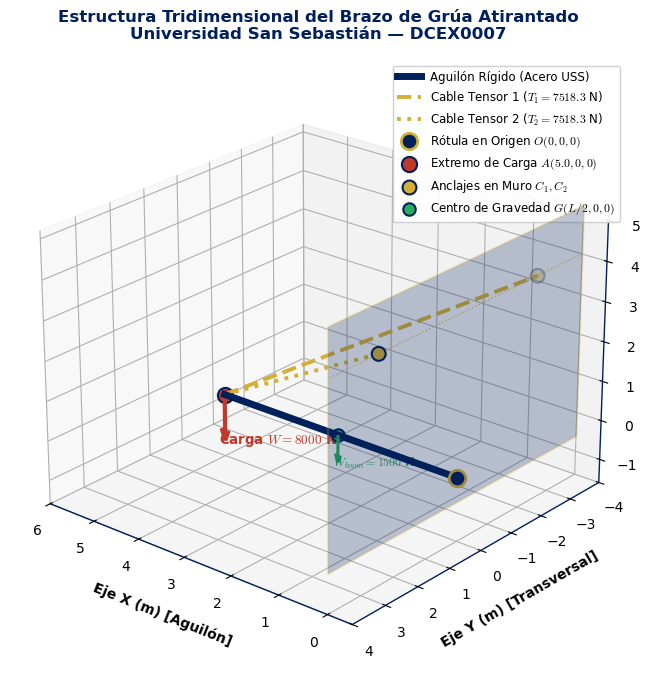

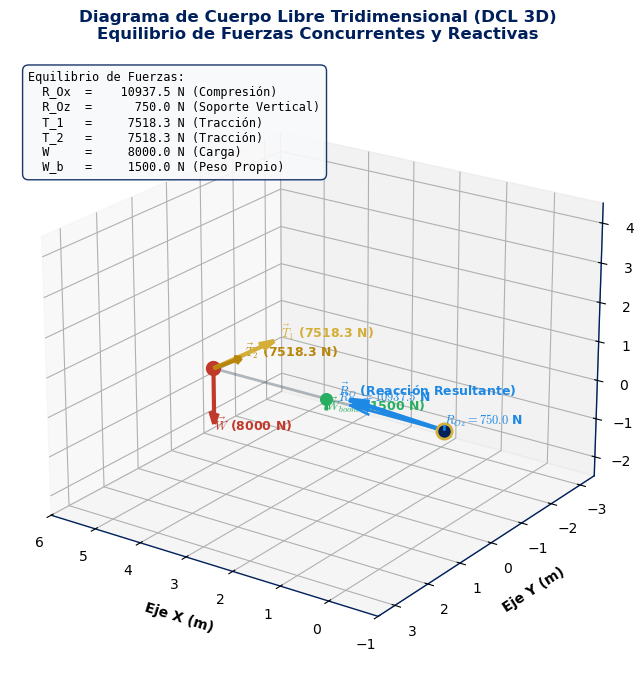

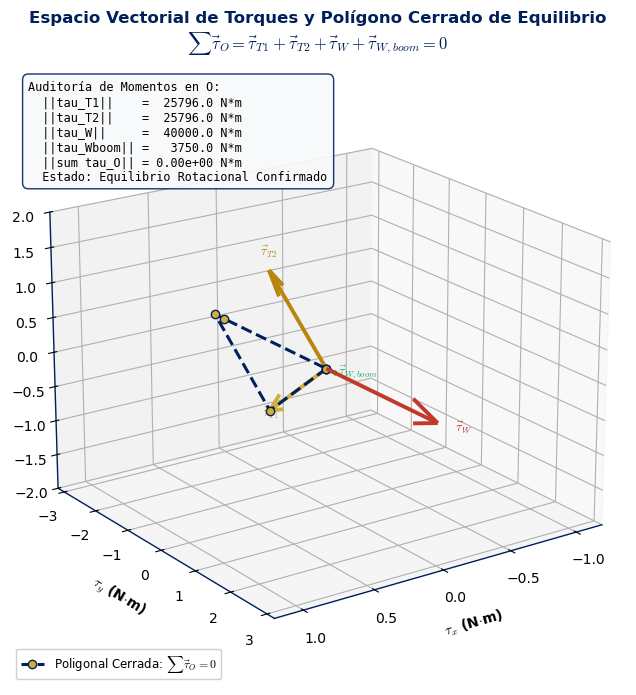

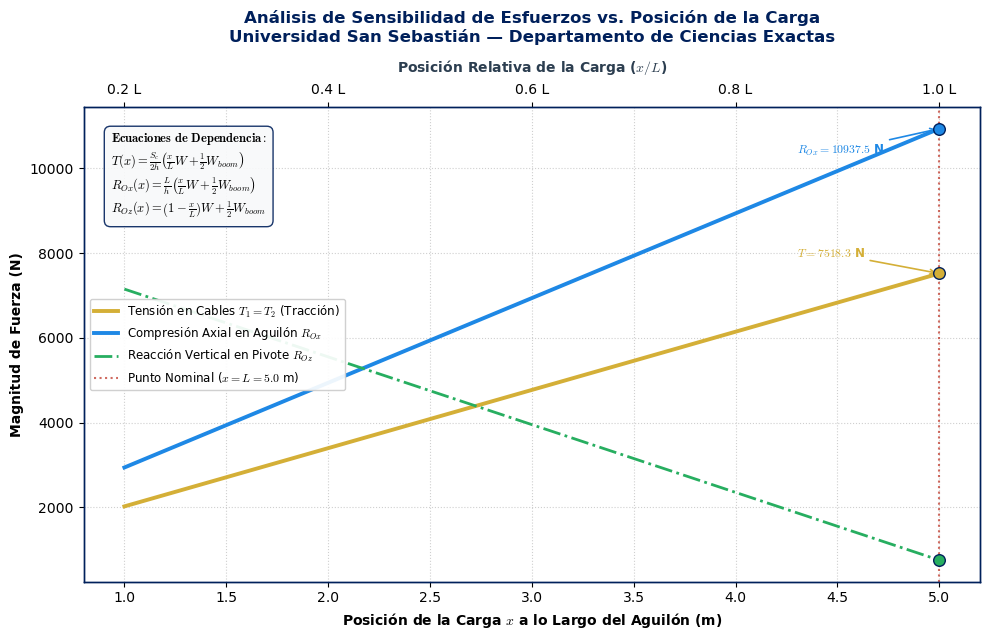

Las 4 figuras independientes han sido generadas y guardadas con éxito.


In [4]:
# ==============================================================================
# Celda 4: Generacion y Despliegue de las 4 Figuras Independientes
# ==============================================================================
import os

# 1. Figura 1: Estructura 3D
fig1 = plt.figure(figsize=(10, 8), facecolor=USS_BG_WHITE)
ax1 = fig1.add_subplot(111, projection="3d")
ax1.set_facecolor(USS_BG_WHITE)

muro_y = res_base["d"] * 1.6
muro_z_max = res_base["h"] * 1.3
verts_muro = [np.array([[0, -muro_y, -0.6], [0, muro_y, -0.6], [0, muro_y, muro_z_max], [0, -muro_y, muro_z_max]])]
muro = Poly3DCollection(verts_muro, alpha=0.25, facecolor=USS_BLUE, edgecolor=USS_GOLD, linewidths=1.5)
ax1.add_collection3d(muro)
ax1.plot([0, 0], [-muro_y, muro_y], [res_base["h"], res_base["h"]], color=USS_GOLD, linestyle=":", linewidth=1.0, alpha=0.7)

ax1.plot([res_base["r_O"][0], res_base["r_A"][0]],
         [res_base["r_O"][1], res_base["r_A"][1]],
         [res_base["r_O"][2], res_base["r_A"][2]],
         color=USS_BLUE, linewidth=5.0, label="Aguilón Rígido (Acero USS)", zorder=5)

ax1.plot([res_base["r_A"][0], res_base["C1"][0]],
         [res_base["r_A"][1], res_base["C1"][1]],
         [res_base["r_A"][2], res_base["C1"][2]],
         color=USS_GOLD, linewidth=2.8, linestyle="--",
         label=f"Cable Tensor 1 ($T_1 = {res_base['T_1']:.1f}$ N)", zorder=4)
ax1.plot([res_base["r_A"][0], res_base["C2"][0]],
         [res_base["r_A"][1], res_base["C2"][1]],
         [res_base["r_A"][2], res_base["C2"][2]],
         color=USS_GOLD, linewidth=2.8, linestyle=":",
         label=f"Cable Tensor 2 ($T_2 = {res_base['T_2']:.1f}$ N)", zorder=4)

ax1.scatter([0], [0], [0], color=USS_BLUE, s=140, edgecolors=USS_GOLD, linewidth=2.0, label="Rótula en Origen $O(0,0,0)$", zorder=6)
ax1.scatter([res_base["r_A"][0]], [res_base["r_A"][1]], [res_base["r_A"][2]],
            color=USS_ACCENT_RED, s=120, edgecolors=USS_BLUE, linewidth=1.5, label=f"Extremo de Carga $A({res_base['L']:.1f}, 0, 0)$", zorder=6)
ax1.scatter([res_base["C1"][0], res_base["C2"][0]], [res_base["C1"][1], res_base["C2"][1]], [res_base["C1"][2], res_base["C2"][2]],
            color=USS_GOLD, s=100, edgecolors=USS_BLUE, linewidth=1.5, label="Anclajes en Muro $C_1, C_2$", zorder=6)

ax1.quiver(res_base["r_A"][0], res_base["r_A"][1], res_base["r_A"][2], 0, 0, -1.2, color=USS_ACCENT_RED, linewidth=3.0, arrow_length_ratio=0.25)
ax1.text(res_base["r_A"][0] + 0.15, 0.0, -1.35, f"Carga $W = {res_base['W_mag']:.0f}$ N", color=USS_ACCENT_RED, fontsize=9.5, fontweight="bold")

ax1.scatter([res_base["r_G"][0]], [res_base["r_G"][1]], [res_base["r_G"][2]],
            color=USS_ACCENT_GREEN, s=80, edgecolors=USS_BLUE, linewidth=1.5, label="Centro de Gravedad $G(L/2, 0, 0)$", zorder=6)
ax1.quiver(res_base["r_G"][0], res_base["r_G"][1], res_base["r_G"][2], 0, 0, -0.7, color=USS_ACCENT_GREEN, linewidth=2.2, arrow_length_ratio=0.3)
ax1.text(res_base["r_G"][0] + 0.1, 0.0, -0.85, f"$W_{{boom}} = {res_base['W_boom']:.0f}$ N", color=USS_ACCENT_GREEN, fontsize=8.5, fontweight="bold")

ax1.set_xlim([-0.5, res_base["L"] + 1.0])
ax1.set_ylim([-muro_y, muro_y])
ax1.set_zlim([-1.6, muro_z_max])
ax1.set_xlabel("Eje X (m) [Aguilón]", fontweight="bold", labelpad=8)
ax1.set_ylabel("Eje Y (m) [Transversal]", fontweight="bold", labelpad=8)
ax1.set_zlabel("Eje Z (m) [Vertical]", fontweight="bold", labelpad=8)
ax1.set_title("Estructura Tridimensional del Brazo de Grúa Atirantado\nUniversidad San Sebastián — DCEX0007",
              fontsize=12, fontweight="bold", color=USS_BLUE, pad=15)
ax1.view_init(elev=24, azim=130)
ax1.legend(loc="upper right", fontsize=8.5, framealpha=0.92)
ax1.grid(True, linestyle=":", alpha=0.5)
plt.savefig("08_estructura_grua_3d.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Figura 2: DCL 3D
fig2 = plt.figure(figsize=(10, 8), facecolor=USS_BG_WHITE)
ax2 = fig2.add_subplot(111, projection="3d")
ax2.set_facecolor(USS_BG_WHITE)
ax2.plot([res_base["r_O"][0], res_base["r_A"][0]], [0, 0], [0, 0],
         color=USS_DARK_GRAY, linewidth=2.0, alpha=0.35, linestyle="-")

fuerza_max = max(res_base["T_1"], res_base["T_2"], abs(res_base["R_Ox"]), res_base["W_mag"])
escala_F = 2.0 / fuerza_max

def dibujar_fuerza(ox, oy, oz, vx, vy, vz, color, label, lw=2.8):
    fx, fy, fz = vx * escala_F, vy * escala_F, vz * escala_F
    ax2.quiver(ox, oy, oz, fx, fy, fz, color=color, linewidth=lw, arrow_length_ratio=0.22, normalize=False)
    ax2.text(ox + fx * 1.12, oy + fy * 1.12, oz + fz * 1.12, label, color=color, fontsize=9.0, fontweight="bold")

R_vec = np.array([res_base["R_Ox"], res_base["R_Oy"], res_base["R_Oz"]])
dibujar_fuerza(0, 0, 0, R_vec[0], R_vec[1], R_vec[2], USS_ACCENT_BLUE, r"$\vec{R}_O$ (Reacción Resultante)", lw=3.2)
dibujar_fuerza(0, 0, 0, res_base["R_Ox"], 0, 0, USS_ACCENT_BLUE, f"$R_{{Ox}} = {res_base['R_Ox']:.1f}$ N", lw=1.8)
dibujar_fuerza(0, 0, 0, 0, 0, res_base["R_Oz"], USS_ACCENT_BLUE, f"$R_{{Oz}} = {res_base['R_Oz']:.1f}$ N", lw=1.8)

f_t1 = res_base["T_1"] * res_base["u1"]
f_t2 = res_base["T_2"] * res_base["u2"]
dibujar_fuerza(res_base["r_A"][0], res_base["r_A"][1], res_base["r_A"][2], f_t1[0], f_t1[1], f_t1[2], USS_GOLD, f"$\\vec{{T}}_1$ ({res_base['T_1']:.1f} N)", lw=3.0)
dibujar_fuerza(res_base["r_A"][0], res_base["r_A"][1], res_base["r_A"][2], f_t2[0], f_t2[1], f_t2[2], "#B8860B", f"$\\vec{{T}}_2$ ({res_base['T_2']:.1f} N)", lw=3.0)
dibujar_fuerza(res_base["r_A"][0], res_base["r_A"][1], res_base["r_A"][2], 0.0, res_base["F_lat_y"], -res_base["W_mag"], USS_ACCENT_RED, f"$\\vec{{W}}$ ({res_base['W_mag']:.0f} N)", lw=3.0)
dibujar_fuerza(res_base["r_G"][0], res_base["r_G"][1], res_base["r_G"][2], 0.0, 0.0, -res_base["W_boom"], USS_ACCENT_GREEN, f"$\\vec{{W}}_{{boom}}$ ({res_base['W_boom']:.0f} N)", lw=2.4)

ax2.scatter([0], [0], [0], color=USS_BLUE, s=120, edgecolors=USS_GOLD, linewidth=2.0)
ax2.scatter([res_base["r_A"][0]], [0], [0], color=USS_ACCENT_RED, s=100)
ax2.scatter([res_base["r_G"][0]], [0], [0], color=USS_ACCENT_GREEN, s=70)

info_dcl = (
    "Equilibrio de Fuerzas:\n"
    f"  R_Ox  = {res_base['R_Ox']:10.1f} N (Compresión)\n"
    f"  R_Oz  = {res_base['R_Oz']:10.1f} N (Soporte Vertical)\n"
    f"  T_1   = {res_base['T_1']:10.1f} N (Tracción)\n"
    f"  T_2   = {res_base['T_2']:10.1f} N (Tracción)\n"
    f"  W     = {res_base['W_mag']:10.1f} N (Carga)\n"
    f"  W_b   = {res_base['W_boom']:10.1f} N (Peso Propio)"
)
ax2.text2D(0.03, 0.82, info_dcl, transform=ax2.transAxes, fontsize=8.5, fontfamily="monospace",
           bbox=dict(boxstyle="round,pad=0.5", facecolor=USS_LIGHT_GRAY, edgecolor=USS_BLUE, alpha=0.9))
ax2.set_xlim([-1.0, res_base["L"] + 1.0])
ax2.set_ylim([-res_base["d"] - 1.0, res_base["d"] + 1.0])
ax2.set_zlim([-2.5, res_base["h"] + 0.5])
ax2.set_xlabel("Eje X (m)", fontweight="bold", labelpad=8)
ax2.set_ylabel("Eje Y (m)", fontweight="bold", labelpad=8)
ax2.set_zlabel("Eje Z (m)", fontweight="bold", labelpad=8)
ax2.set_title("Diagrama de Cuerpo Libre Tridimensional (DCL 3D)\nEquilibrio de Fuerzas Concurrentes y Reactivas",
              fontsize=12, fontweight="bold", color=USS_BLUE, pad=15)
ax2.view_init(elev=22, azim=125)
ax2.grid(True, linestyle=":", alpha=0.5)
plt.savefig("08_diagrama_cuerpo_libre_3d.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Figura 3: Espacio de Torques
fig3 = plt.figure(figsize=(10, 8), facecolor=USS_BG_WHITE)
ax3 = fig3.add_subplot(111, projection="3d")
ax3.set_facecolor(USS_BG_WHITE)

tau_T1 = np.cross(res_base["r_A"], res_base["T_1"] * res_base["u1"])
tau_T2 = np.cross(res_base["r_A"], res_base["T_2"] * res_base["u2"])
tau_W  = np.cross(res_base["r_A"], np.array([0.0, 0.0, -res_base["W_mag"]]))
tau_Wb = np.cross(res_base["r_G"], np.array([0.0, 0.0, -res_base["W_boom"]]))
tau_M  = np.array([res_base["M_Ox"], 0.0, 0.0])

max_tau = max(np.linalg.norm(tau_T1), np.linalg.norm(tau_T2), np.linalg.norm(tau_W), 1.0)
escala_tau = 3.0 / max_tau

def dibujar_torque(origen, vec_tau, color, label):
    ox, oy, oz = origen
    vx, vy, vz = vec_tau * escala_tau
    ax3.quiver(ox, oy, oz, vx, vy, vz, color=color, linewidth=2.8, arrow_length_ratio=0.22, normalize=False)
    ax3.text(ox + vx * 1.15, oy + vy * 1.15, oz + vz * 1.15, label, color=color, fontsize=9.0, fontweight="bold")

orig_0 = np.array([0.0, 0.0, 0.0])
dibujar_torque(orig_0, tau_T1, USS_GOLD, r"$\vec{\tau}_{T1}$")
dibujar_torque(orig_0, tau_T2, "#B8860B", r"$\vec{\tau}_{T2}$")
dibujar_torque(orig_0, tau_W, USS_ACCENT_RED, r"$\vec{\tau}_W$")
dibujar_torque(orig_0, tau_Wb, USS_ACCENT_GREEN, r"$\vec{\tau}_{W,boom}$")

p0 = orig_0
p1 = p0 + tau_T1 * escala_tau
p2 = p1 + tau_T2 * escala_tau
p3 = p2 + tau_Wb * escala_tau
p4 = p3 + tau_W * escala_tau
p5 = p4 + tau_M * escala_tau
cadena = np.array([p0, p1, p2, p3, p4, p5])

ax3.plot(cadena[:, 0], cadena[:, 1], cadena[:, 2], color=USS_BLUE, linestyle="--", linewidth=2.2,
         marker="o", markersize=6, markerfacecolor=USS_GOLD, markeredgecolor=USS_BLUE,
         label=r"Poligonal Cerrada: $\sum \vec{\tau}_O = \mathbf{0}$", zorder=5)

info_tau = (
    "Auditoría de Momentos en O:\n"
    f"  ||tau_T1||    = {np.linalg.norm(tau_T1):8.1f} N*m\n"
    f"  ||tau_T2||    = {np.linalg.norm(tau_T2):8.1f} N*m\n"
    f"  ||tau_W||     = {np.linalg.norm(tau_W):8.1f} N*m\n"
    f"  ||tau_Wboom|| = {np.linalg.norm(tau_Wb):8.1f} N*m\n"
    f"  ||sum tau_O|| = {res_base['norm_tau']:.2e} N*m\n"
    "  Estado: Equilibrio Rotacional Confirmado"
)
ax3.text2D(0.03, 0.82, info_tau, transform=ax3.transAxes, fontsize=8.5, fontfamily="monospace",
           bbox=dict(boxstyle="round,pad=0.5", facecolor=USS_LIGHT_GRAY, edgecolor=USS_BLUE, alpha=0.9))
lim_t = 3.2
ax3.set_xlim([-1.2, 1.2])
ax3.set_ylim([-lim_t, lim_t])
ax3.set_zlim([-2.0, 2.0])
ax3.set_xlabel(r"$\tau_x$ (N$\cdot$m)", fontweight="bold", labelpad=8)
ax3.set_ylabel(r"$\tau_y$ (N$\cdot$m)", fontweight="bold", labelpad=8)
ax3.set_zlabel(r"$\tau_z$ (N$\cdot$m)", fontweight="bold", labelpad=8)
ax3.set_title("Espacio Vectorial de Torques y Polígono Cerrado de Equilibrio\n" +
              r"$\sum \vec{\tau}_O = \vec{\tau}_{T1} + \vec{\tau}_{T2} + \vec{\tau}_W + \vec{\tau}_{W,boom} = \mathbf{0}$",
              fontsize=12, fontweight="bold", color=USS_BLUE, pad=15)
ax3.view_init(elev=20, azim=55)
ax3.legend(loc="lower left", fontsize=8.5, framealpha=0.92)
ax3.grid(True, linestyle=":", alpha=0.5)
plt.savefig("08_espacio_torques_equilibrio_3d.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. Figura 4: Sensibilidad 2D
fig4, ax4 = plt.subplots(figsize=(10, 6.5), facecolor=USS_BG_WHITE)
ax4.set_facecolor(USS_BG_WHITE)

posiciones_x = np.linspace(0.2 * res_base["L"], res_base["L"], 80)
t1_vals, t2_vals, rox_vals, roz_vals = [], [], [], []
for x_c in posiciones_x:
    r_temp = resolver_equilibrio_estatico_3d(x_carga=x_c)
    t1_vals.append(r_temp["T_1"])
    t2_vals.append(r_temp["T_2"])
    rox_vals.append(r_temp["R_Ox"])
    roz_vals.append(r_temp["R_Oz"])

ax4.plot(posiciones_x, t1_vals, color=USS_GOLD, linewidth=2.8, label=r"Tensión en Cables $T_1 = T_2$ (Tracción)")
ax4.plot(posiciones_x, rox_vals, color=USS_ACCENT_BLUE, linewidth=2.8, label=r"Compresión Axial en Aguilón $R_{Ox}$")
ax4.plot(posiciones_x, roz_vals, color=USS_ACCENT_GREEN, linewidth=2.0, linestyle="-.", label=r"Reacción Vertical en Pivote $R_{Oz}$")

pos_nom = res_base["L"]
ax4.axvline(pos_nom, color=USS_ACCENT_RED, linestyle=":", alpha=0.75, linewidth=1.5, label=f"Punto Nominal ($x = L = {pos_nom:.1f}$ m)")
ax4.scatter([pos_nom], [res_base["T_1"]], color=USS_GOLD, s=70, zorder=5, edgecolors=USS_BLUE)
ax4.scatter([pos_nom], [res_base["R_Ox"]], color=USS_ACCENT_BLUE, s=70, zorder=5, edgecolors=USS_BLUE)
ax4.scatter([pos_nom], [res_base["R_Oz"]], color=USS_ACCENT_GREEN, s=70, zorder=5, edgecolors=USS_BLUE)

ax4.annotate(f"$T = {res_base['T_1']:.1f}$ N", xy=(pos_nom, res_base["T_1"]),
             xytext=(pos_nom - 0.7, res_base["T_1"] + 400), fontsize=8.5, fontweight="bold", color=USS_GOLD,
             arrowprops=dict(arrowstyle="->", color=USS_GOLD, lw=1.2))
ax4.annotate(f"$R_{{Ox}} = {res_base['R_Ox']:.1f}$ N", xy=(pos_nom, res_base["R_Ox"]),
             xytext=(pos_nom - 0.7, res_base["R_Ox"] - 600), fontsize=8.5, fontweight="bold", color=USS_ACCENT_BLUE,
             arrowprops=dict(arrowstyle="->", color=USS_ACCENT_BLUE, lw=1.2))

info_formulas = (
    r"$\mathbf{Ecuaciones\ de\ Dependencia:}$" + "\n" +
    r"$T(x) = \frac{S_c}{2h} \left(\frac{x}{L} W + \frac{1}{2} W_{boom}\right)$" + "\n" +
    r"$R_{Ox}(x) = \frac{L}{h} \left(\frac{x}{L} W + \frac{1}{2} W_{boom}\right)$" + "\n" +
    r"$R_{Oz}(x) = \left(1 - \frac{x}{L}\right) W + \frac{1}{2} W_{boom}$"
)
ax4.text(0.03, 0.95, info_formulas, transform=ax4.transAxes, verticalalignment="top", fontsize=9.0,
         bbox=dict(boxstyle="round,pad=0.5", facecolor=USS_LIGHT_GRAY, edgecolor=USS_BLUE, alpha=0.9))
ax4.set_xlabel("Posición de la Carga $x$ a lo Largo del Aguilón (m)", fontweight="bold")
ax4.set_ylabel("Magnitud de Fuerza (N)", fontweight="bold")
ax4.set_title("Análisis de Sensibilidad de Esfuerzos vs. Posición de la Carga\n" +
              "Universidad San Sebastián — Departamento de Ciencias Exactas",
              fontsize=12, fontweight="bold", color=USS_BLUE, pad=12)
ax4.grid(True, linestyle=":", alpha=0.6)
ax4.legend(loc="center left", fontsize=8.5, framealpha=0.92)

ax4_top = ax4.twiny()
ax4_top.set_xlim(ax4.get_xlim())
ticks_x = np.linspace(1.0, res_base["L"], 5)
ax4_top.set_xticks(ticks_x)
ax4_top.set_xticklabels([f"{t / res_base['L']:.1f} L" for t in ticks_x])
ax4_top.set_xlabel("Posición Relativa de la Carga ($x / L$)", fontweight="bold", color=USS_DARK_GRAY, labelpad=8)

plt.tight_layout()
plt.savefig("08_analisis_sensibilidad_tensiones_2d.png", dpi=300, bbox_inches="tight")
plt.show()
print("Las 4 figuras independientes han sido generadas y guardadas con éxito.")


### 4.1 Simulador Interactivo de Equilibrio Estático en Tiempo Real
[Simulación Computacional y Robótica]

El siguiente simulador interactivo permite explorar el comportamiento del sistema mecánico modificando en tiempo real:
- $L$: Longitud del aguilón (m).
- $W$: Carga gravitacional suspendida en la punta (N).
- $F_{lat}$: Fuerza lateral de viento transversal (N).
- $h$: Altura de los anclajes en el muro (m).
- $d$: Semiancho de separación de los anclajes (m).

> [!TIP]
> **Casos Notables de Experimentación:**
> 1. **Comportamiento Asintótico ($h \to 0$):** Al reducir la altura $h$, el ángulo formado por los cables con la horizontal disminuye, provocando que la tensión necesaria tienda asintóticamente a infinito ($T \to \infty$).
> 2. **Viento Lateral y Destensamiento:** Modifique $F_{lat}$ para comprobar la rotura de la simetría: un cable asume mayor esfuerzo de tracción mientras que el opuesto se descarga. Si $F_{lat}$ supera el umbral admisible, la tensión calculada se volvería negativa, indicando fallo por destensamiento (*cable slackening*).


In [5]:
# ==============================================================================
# Celda 5: Interfaz Interactiva con ipywidgets en Tiempo Real
# ==============================================================================
@widgets.interact(
    L=widgets.FloatSlider(value=5.0, min=2.0, max=10.0, step=0.5, description="Brazo L (m):", continuous_update=False),
    W=widgets.FloatSlider(value=8000.0, min=1000.0, max=20000.0, step=500.0, description="Carga W (N):", continuous_update=False),
    F_lat=widgets.FloatSlider(value=0.0, min=-3000.0, max=3000.0, step=250.0, description="Viento F_lat (N):", continuous_update=False),
    h=widgets.FloatSlider(value=4.0, min=1.5, max=8.0, step=0.5, description="Altura h (m):", continuous_update=False),
    d=widgets.FloatSlider(value=2.5, min=1.0, max=5.0, step=0.5, description="Ancho d (m):", continuous_update=False)
)
def actualizar_simulacion(L, W, F_lat, h, d):
    res = resolver_equilibrio_estatico_3d(L=L, d=d, h=h, W_mag=W, F_lat_y=F_lat, W_boom=1500.0)
    
    estado_t1 = "Tracción Segura (T1 > 0)" if res["T_1"] > 0 else "Cable Destensado (Fallo Estructural: T1 <= 0)"
    estado_t2 = "Tracción Segura (T2 > 0)" if res["T_2"] > 0 else "Cable Destensado (Fallo Estructural: T2 <= 0)"
    estado_cond = "Excelente (< 10)" if res["cond_A"] < 10 else ("Aceptable" if res["cond_A"] < 30 else "Pobre (Cercano a Singularidad)")
    
    display(Markdown(f"""
### Métricas Estructurales del Sistema en Tiempo Real:
| Variable de Reacción / Esfuerzo | Valor Numérico | Estado Físico / Condición de Diseño |
|:---|:---:|:---|
| **Tensión Cable 1 ($T_1$)** | `{res['T_1']:.2f} N` | {estado_t1} |
| **Tensión Cable 2 ($T_2$)** | `{res['T_2']:.2f} N` | {estado_t2} |
| **Compresión en Rótula ($R_{{Ox}}$)** | `{res['R_Ox']:.2f} N` | Esfuerzo axial transmitido al soporte |
| **Reacción Lateral ($R_{{Oy}}$)** | `{res['R_Oy']:.2f} N` | Reacción frente a empuje transversal |
| **Reacción Vertical ($R_{{Oz}}$)** | `{res['R_Oz']:.2f} N` | Soporte basal del peso propio |
| **Momento Reactivo Axial ($M_{{Ox}}$)** | `{res['M_Ox']:.2f} N·m` | Restricción torsional sobre el aguilón |
| **Número de Condición $\\kappa(\\mathbf{{A}})$** | `{res['cond_A']:.2f}` | {estado_cond} |
| **Residuo Euclidiano $\\|\\mathbf{{A}}\\mathbf{{x}} - \\mathbf{{b}}\\|$** | `{res['residuo']:.2e} N` | Consistencia numérica de la solución |
    """))


interactive(children=(FloatSlider(value=5.0, continuous_update=False, description='Brazo L (m):', max=10.0, mi…

### 4.2 Conclusiones y Preguntas de Razonamiento Estructural
[Texto Guía — Sears-Zemansky / Marion / Grossman]

1. **Efecto de la Altura de Anclaje $h$ en la Tensión de los Cables:**
   A partir de la solución analítica deducida formalmente mediante SymPy:
   $$T_1 = T_2 = \frac{(2W + W_{boom}) \sqrt{L^2 + d^2 + h^2}}{4h}$$
   Cuando $h \to 0$, el denominador tiende a cero y $T \to \infty$. Físicamente, un cable horizontal carece por completo de componente vertical para equilibrar el peso gravitacional; se requeriría una tensión teóricamente infinita para sostener cualquier carga finita.

2. **Restricción Unilateral de Tracción en Cables ($T_i \ge 0$):**
   Los cables de acero son elementos estructurales unidireccionales que admiten exclusivamente esfuerzos de tracción ($T_i \ge 0$). Si una fuerza transversal extrema $F_{lat}$ provoca que la formulación lineal arroje $T_2 < 0$, el cable sufre destensamiento (*cable slackening*), perdiendo toda rigidez y transformando la estructura en un mecanismo cinemático inestable.

3. **Relevancia del Álgebra Lineal en la Ingeniería Estructural:**
   La formulación matricial $\mathbf{A}\mathbf{x} = \mathbf{b}$ transforma las leyes vectoriales de la física newtoniana en un problema de inversión matricial directa resoluble en microsegundos. Este principio constituye el núcleo conceptual del método de elementos finitos (FEM / FEA) y del análisis estático y dinámico en robótica espacial e industrial.

---
### Conexiones del Ecosistema Bóveda USS:
- [[algebra_lineal_dashboard|Panel General de Álgebra Lineal]]
- [[08_estructura_grua_3d.png|Modelo Físico 3D de la Grúa]]
- [[08_diagrama_cuerpo_libre_3d.png|Diagrama de Cuerpo Libre 3D]]
- [[08_espacio_torques_equilibrio_3d.png|Espacio Vectorial de Torques y Polígono Cerrado]]
- [[08_analisis_sensibilidad_tensiones_2d.png|Análisis de Sensibilidad de Esfuerzos 2D]]
- [[08_simulacion_torque_y_equilibrio_3d.py|Script Ejecutable Autónomo Python]]
